# **DM Python pour la Datascience**

### Installation des packages nécessaires

In [1]:
%pip install -q great_tables
%pip install -q cartiflette
%pip install -q great_tables
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Import des packages

In [2]:
import pandas as pd
from great_tables import GT, style, loc,md
from graphiques_surrepresentation import plot_carte_surrepresentation, plot_surrepresentation
import warnings
warnings.filterwarnings('ignore')

### Import du jeu de données

In [3]:
df = pd.read_csv(
'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)
df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


## 1. Explorations générales
### Question 1

Créer ou mettre à jour les variables suivantes:
• code_commune: En utilisant la variable déjà existante et le département, remplacer la valeur code_commune pour constituer un vrai code commune. Par exemple, pour Montrouge, vous devriez obtenir 92049.
• candidat: créer une colonne avec le prenom et le nom mis ensemble, en n’oubliant pas de mettre un espace. Ne pas éliminer les bulletins abstentions, blancs ou nuls, nous allons les exploiter ultérieurement.

In [4]:
df['code_commune'] = df['code_departement'].astype(str) + df['code_commune'].astype(str).str.zfill(3)
df['candidat'] = df['prenom'] + ' ' + df['nom']
df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,Nathalie ARTHAUD
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8,Nathalie ARTHAUD
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0,Nathalie ARTHAUD


### Question 2
Compléter la phrase suivante grâce à Python:
En 2022, il y avait XXXXX candidats à l’élection présidentielle
Note: Attention aux votes non exprimés et aux abstentions

In [5]:
nombre_candidats = df['candidat'].nunique()
print(f"En 2022, il y avait {nombre_candidats} candidats à l’élection présidentielle.")

En 2022, il y avait 12 candidats à l’élection présidentielle.


### Question 3

Calculer les scores nationaux de chaque candidat. Représenter dans ce tableau, pour chaque candidat, le nombre de voix et le pourcatage des votes exprimés (c’est-à-dire en retirant abstentions et votes non exprimés).
Représenter cela dans un dataframe ou, pour avoir tous les points, dans un tableau mis en forme via great_tables (il n’est pas obligatoire d’aller aussi loin dans la mise en forme mais essayez d’obtenir un beau tableau tout de même).

In [6]:
scores_nationaux = df.groupby('candidat')['voix'].sum().reset_index()
scores_nationaux['pourcentage'] = (scores_nationaux['voix'] / scores_nationaux['voix'].sum())
scores_nationaux = scores_nationaux.sort_values(by='voix', ascending=False)
scores_nationaux.head()


,candidat,voix,pourcentage
1,Emmanuel MACRON,9783058,0.278458
5,Marine LE PEN,8133828,0.231516
4,Jean-Luc MÉLENCHON,7712520,0.219524
11,Éric ZEMMOUR,2485226,0.070738
9,Valérie PÉCRESSE,1679001,0.047790


In [7]:
(
    GT(scores_nationaux[["candidat", "voix", "pourcentage"]])
    .tab_header(
        title=md("**Elections**"), 
        subtitle="Résultats du premier tour (📅 10 avril 2022)"
    )
    .cols_label(
        candidat="Candidat", 
        voix="Nombre votes (total)", 
        pourcentage="Score (% votes exprimés)"
    )
    .fmt_integer(columns="voix", sep_mark=" ")
    .fmt_percent(columns="pourcentage", decimals=2)
    .opt_table_font(font="Times New Roman")
    .tab_style(
        style=style.text(align="center"), 
        locations=[loc.title(), loc.subtitle()]
    )
)

GT(_tbl_data=                 candidat     voix  pourcentage
1         Emmanuel MACRON  9783058     0.278458
5           Marine LE PEN  8133828     0.231516
4      Jean-Luc MÉLENCHON  7712520     0.219524
11           Éric ZEMMOUR  2485226     0.070738
9        Valérie PÉCRESSE  1679001     0.047790
10          Yannick JADOT  1627853     0.046334
3           Jean LASSALLE  1101387     0.031349
2          Fabien ROUSSEL   802422     0.022840
7   Nicolas DUPONT-AIGNAN   725176     0.020641
0            Anne HIDALGO   616478     0.017547
8         Philippe POUTOU   268904     0.007654
6        Nathalie ARTHAUD   197094     0.005610, _body=<great_tables._gt_data.Body object at 0x7f7339db1d30>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='pourcentage', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7339db16a0>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Elections**'), subtitle='Résultats du premier tour (📅 10 avril 2022)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7339db2270>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7339f0ead0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7f7339db23c0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7339db2120>, <great_tables._gt_data.FormatInfo object at 0x7f7339f0ec10>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Times New Roman', '-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_bord

## 2. Comparaison des scores départements aux moyennes nationales.
### Question 4

Créer un dataframe nommé score_departements stockant, pour chaque département, le nombre de vote obtenu pour chaque candidat et le score (en %).

In [8]:
score_departements = df.groupby(['code_departement', 'candidat'])['voix'].sum().reset_index()
score_departements['score'] = (score_departements['voix'] / score_departements.groupby('code_departement')['voix'].transform('sum')) * 100
score_departements= score_departements.rename(columns={"voix": "votes"})

score_dept_11 = (
    score_departements[score_departements['code_departement'] == "11"]
    .sort_values(by='score', ascending=False)
)

(
    GT(score_dept_11[["code_departement", "candidat", "votes", "score"]])
    .fmt_number(columns="score", decimals=2, pattern="{x} %")
    .opt_table_font(font="Times New Roman")
)

code_departement,candidat,votes,score
11,Marine LE PEN,64027,30.14 %
11,Emmanuel MACRON,43104,20.29 %
11,Jean-Luc MÉLENCHON,42039,19.79 %
11,Éric ZEMMOUR,18434,8.68 %
11,Jean LASSALLE,12382,5.83 %
11,Valérie PÉCRESSE,7350,3.46 %
11,Yannick JADOT,6322,2.98 %
11,Anne HIDALGO,6166,2.90 %
11,Fabien ROUSSEL,5622,2.65 %
11,Nicolas DUPONT-AIGNAN,4206,1.98 %


### Question 5
Refaire le lien avec le niveau national pour comparer le score départemental avec le score national. Nommer ce dataframe score_departements, nous allons le réutiliser par la suite.

In [9]:
score_departements = score_departements.merge(scores_nationaux[['candidat', 'voix', 'pourcentage']],
                                              on='candidat',
                                              how='left')

score_departements = score_departements.rename(columns={"votes": "votes_departement",
                                                        "score":"score_departement",
                                                        "voix": "votes_national",
                                                        "pourcentage": "score_national"})

score_departement_11 = score_departements[score_departements['code_departement'] == "11"].sort_values(by='score_departement', ascending=False).reset_index(drop=True)
score_departement_11["score_departement"] = score_departement_11["score_departement"].apply(lambda x: f"{x:.2f} %")
score_departement_11["score_national"] = score_departement_11["score_national"].apply(lambda x: f"{x*100:.2f} %")


score_departement_11.head()

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
0,11,Marine LE PEN,64027,30.14 %,8133828,23.15 %
1,11,Emmanuel MACRON,43104,20.29 %,9783058,27.85 %
2,11,Jean-Luc MÉLENCHON,42039,19.79 %,7712520,21.95 %
3,11,Éric ZEMMOUR,18434,8.68 %,2485226,7.07 %
4,11,Jean LASSALLE,12382,5.83 %,1101387,3.13 %


In [10]:
(
    GT(score_departement_11[["code_departement", "candidat", "votes_departement", "score_departement", "votes_national", "score_national"]].head(5))
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.body())
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.column_labels())
)

code_departement,candidat,votes_departement,score_departement,votes_national,score_national
11,Marine LE PEN,64027,30.14 %,8133828,23.15 %
11,Emmanuel MACRON,43104,20.29 %,9783058,27.85 %
11,Jean-Luc MÉLENCHON,42039,19.79 %,7712520,21.95 %
11,Éric ZEMMOUR,18434,8.68 %,2485226,7.07 %
11,Jean LASSALLE,12382,5.83 %,1101387,3.13 %


### Question 6
Créer une variable surrepresentation qui compare, en relatif, les scores nationaux et départe mentaux.
Par exemple, si un candidat a un score de 30% dans un département mais de 15% ailleurs, la valeur de surrepresentation sera égale à 100 (%).

In [11]:
score_departements['surrepresentation'] = (
    (score_departements['score_departement'] - (score_departements['score_national'] * 100)) 
    / (score_departements['score_national'] * 100)
)
print(score_departements.head())

  code_departement            candidat  votes_departement  score_departement  \
0               01        Anne HIDALGO               5644           1.694773   
1               01     Emmanuel MACRON              92206          27.687494   
2               01      Fabien ROUSSEL               5938           1.783055   
3               01       Jean LASSALLE              10876           3.265831   
4               01  Jean-Luc MÉLENCHON              57832          17.365715   

   votes_national  score_national  surrepresentation  
0          616478        0.017547          -0.034153  
1         9783058        0.278458          -0.005686  
2          802422        0.022840          -0.219314  
3         1101387        0.031349           0.041761  
4         7712520        0.219524          -0.208937  


### Question 7
Créer une fonction pour représenter une figure similaire à Figure 1 pour un candidat donné des principales surreprésentations (en valeur absolue) par département.

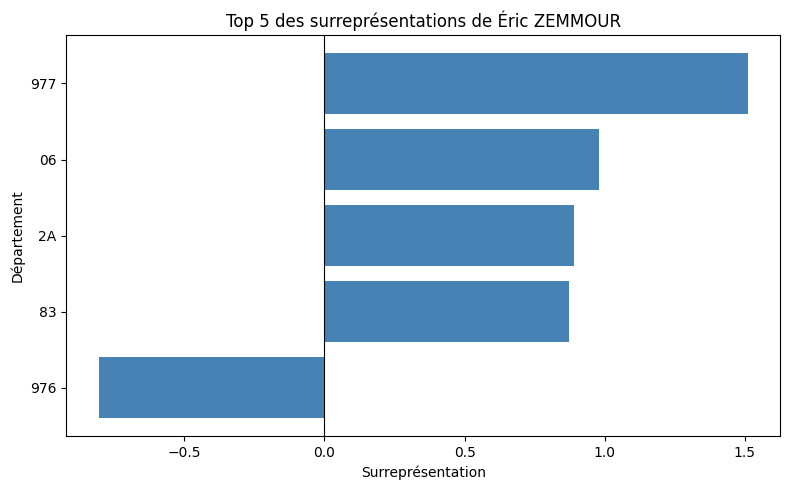

In [12]:
plot_surrepresentation('Éric ZEMMOUR', score_departements)

### Question 8
Faire une fonction permettant de restreindre score_departements en fonction d’un candidat. Commencer par tester sur Marine Le Pen (créer un nouvel objet, ne pas écraser score_departements nous allons l’utiliser à nouveau !).
Faire une jointure au fond de carte des départements et effectuer une carte de la représentation.

In [13]:
from cartiflette import carti_download
departement_borders = carti_download(
 values = ["France"],
 crs = 4326,
 borders = "DEPARTEMENT",
 vectorfile_format="geojson",
 simplification=50,
 filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
 source="EXPRESS-COG-CARTO-TERRITOIRE",
 year=2022)

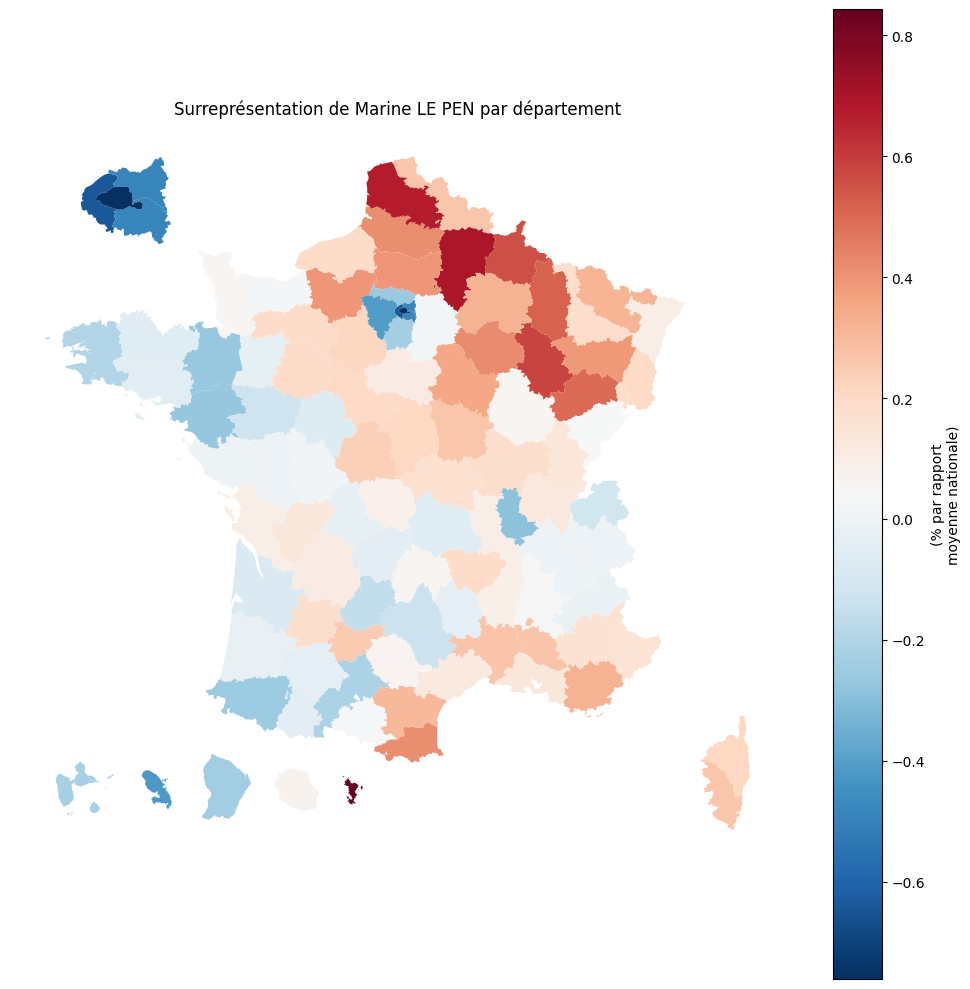

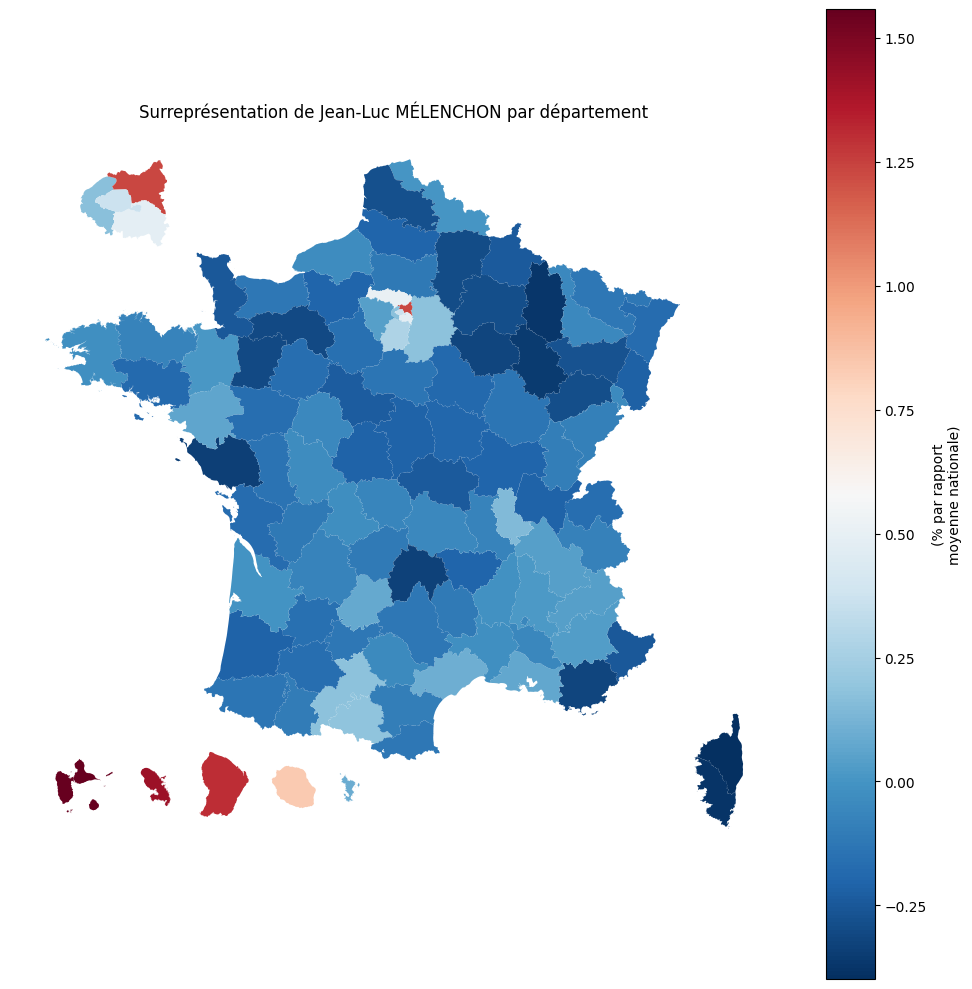

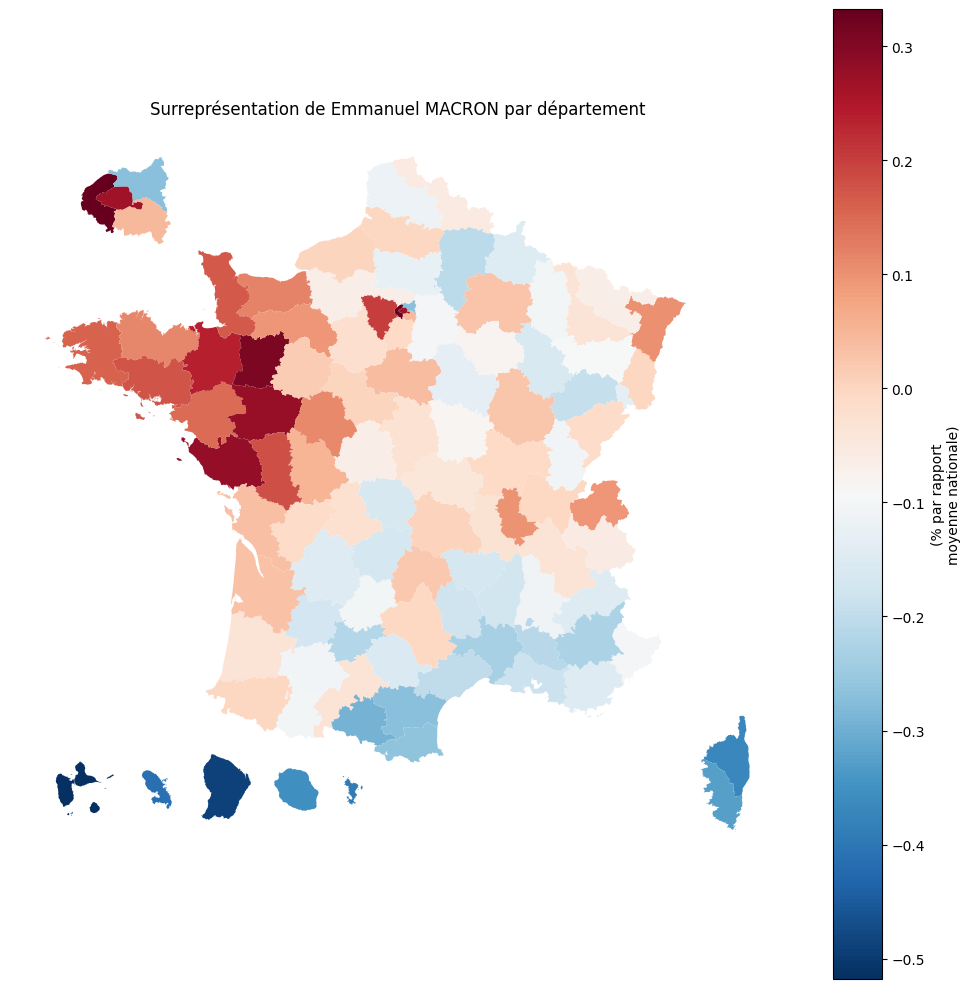

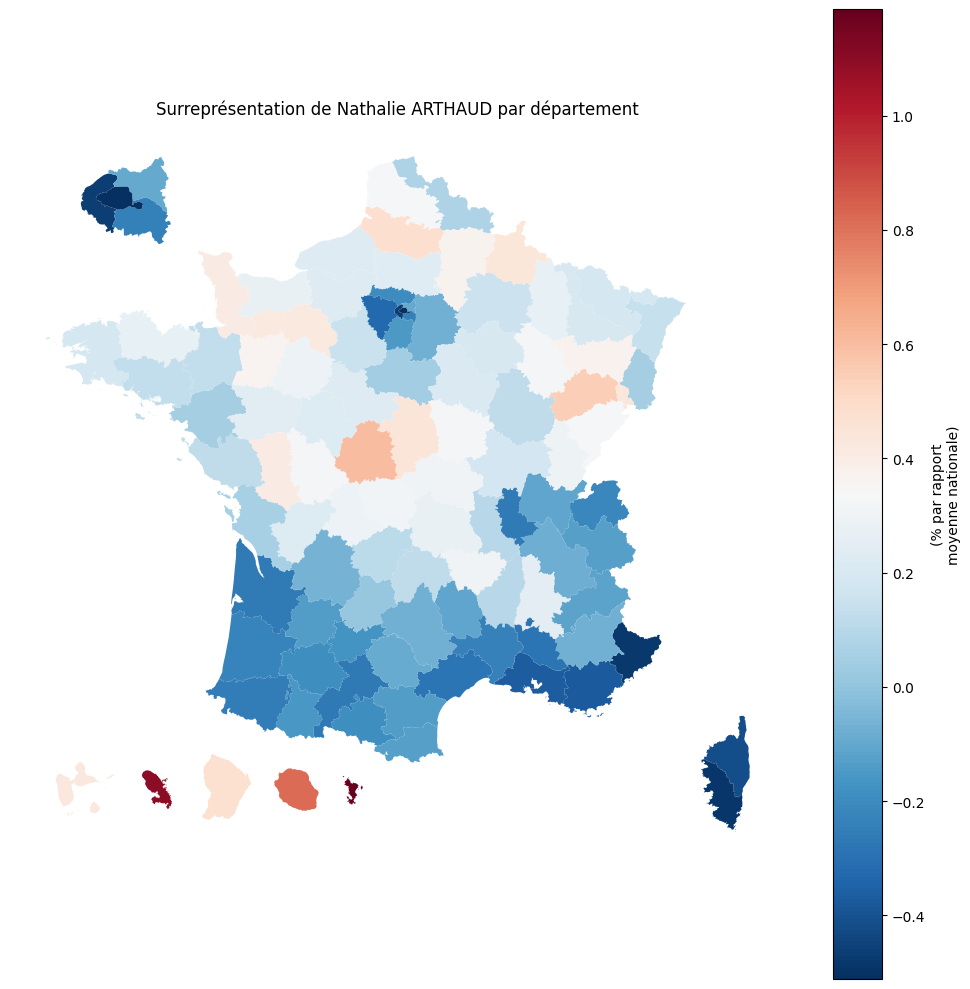

In [14]:
plot_carte_surrepresentation('Marine LE PEN', score_departements, departement_borders)
plot_carte_surrepresentation('Jean-Luc MÉLENCHON', score_departements, departement_borders)
plot_carte_surrepresentation('Emmanuel MACRON', score_departements, departement_borders)
plot_carte_surrepresentation('Nathalie ARTHAUD', score_departements, departement_borders)